<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB
Total Contacts: 45211
Conversions: 5289
Conversion Rate: 0.11698480458295547
Leads: 22551
Lead Rate: 0.4987945411514897
Lead → Conver

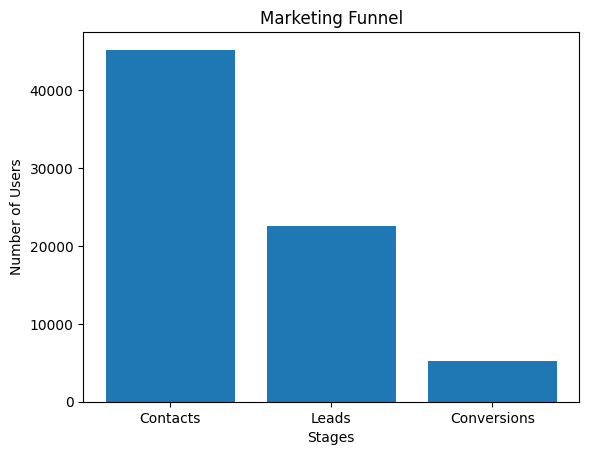

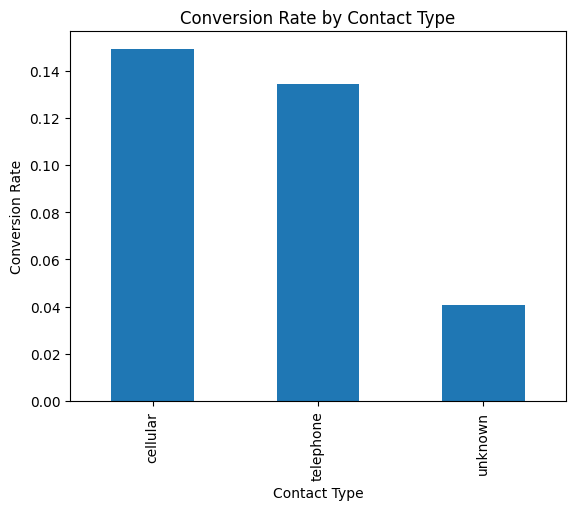

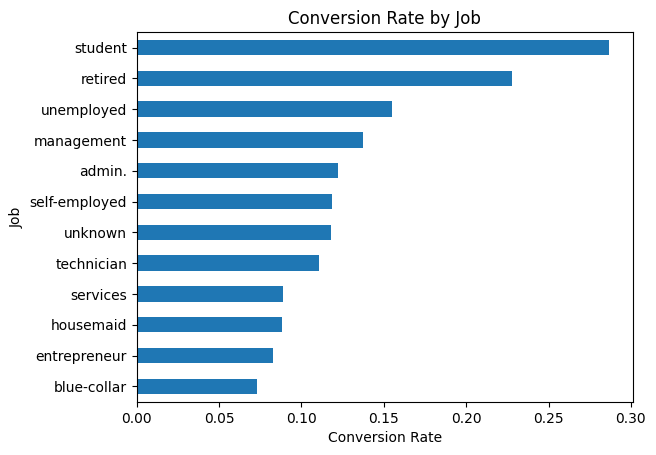

campaign
1     0.145976
2     0.112035
3     0.111936
4     0.090006
5     0.078798
6     0.071263
7     0.063946
8     0.059259
9     0.064220
10    0.052632
Name: conversion, dtype: float64

In [16]:
import pandas as pd

# Load dataset
df = pd.read_csv("bank-full.csv", sep=';')

# Show first 5 rows
df.head()

df.info()
df.describe()

df['conversion'] = df['y'].map({'yes': 1, 'no': 0})

total_contacts = len(df)
total_conversions = df['conversion'].sum()

conversion_rate = total_conversions / total_contacts

print("Total Contacts:", total_contacts)
print("Conversions:", total_conversions)
print("Conversion Rate:", conversion_rate)

df['is_lead'] = df['duration'] > 180 
leads = df['is_lead'].sum()

print("Leads:", leads)
print("Lead Rate:", leads / total_contacts)
print("Lead → Conversion Rate:", total_conversions / leads)

df[['duration', 'is_lead']].head()

lead_threshold = 180
df['is_lead'] = df['duration'] > lead_threshold

df.groupby('contact')['conversion'].mean()


import matplotlib.pyplot as plt

stages = ['Contacts', 'Leads', 'Conversions']
values = [total_contacts, leads, total_conversions]

plt.figure()
plt.bar(stages, values)
plt.title("Marketing Funnel")
plt.xlabel("Stages")
plt.ylabel("Number of Users")
plt.show()

channel_conversion = df.groupby('contact')['conversion'].mean()

plt.figure()
channel_conversion.plot(kind='bar')
plt.title("Conversion Rate by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Conversion Rate")
plt.show()

job_conversion = df.groupby('job')['conversion'].mean().sort_values()

plt.figure()
job_conversion.plot(kind='barh')
plt.title("Conversion Rate by Job")
plt.xlabel("Conversion Rate")
plt.ylabel("Job")
plt.show()

df.groupby('campaign')['conversion'].mean().head(10)

🔥 High-Quality Recommendations

Focus marketing efforts on high-performing channels (e.g., cellular)
Reduce number of repeated contacts to avoid customer fatigue
Target high-converting customer segments (job categories)
Improve final conversion step (offer clarity, urgency, incentives)